In [25]:
import numpy as np
import torch 
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader

import sigkernel as ksig_pde
import sigkernel_ as ksig_disc
import utils.data
from generators.synthetic_generators import *
from generators.ESN import ESNGenerator, ESNAsTarget
from models.trainer_ESN_MMD import train_ESN_MMD
from sigkernel_.loss import compute_mmd_loss
from utils.analyse_training import plot_loss_from_run, inspect_run_and_mmd, acf_analysis, plot_W_history_vs_fixed, plot_terminal_histograms
from utils.kernel_helpers import median_heuristic_sigma, tune_tau_coef_for_cv

%load_ext autoreload
%autoreload 2

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
dtype=torch.float64

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Generator and ESN

In [35]:
T = 50 # length of time series
N = 1000  # number of samples
batch_size = 100
N_target = 100
target_rho = 0.99
xi_ma_theta = None # based on the ACF at the end
d = 1   # dimension of time series
    
# Shared by both ESN
h, m, d = 3, 1, 1 # ESN hyperparameters: reservoir size, input dimension (\xi : randomness), output dimension
activation = "tanh"
quad_feedback = False # whether to include quadratic feedback in the ESN reservoir (to capture some nonlinearity and volatility clustering)
quad_gain = 0.0 # if set to 0.0 then no quadratic feedback
xi_scale = 1.0
eta_scale = 0.0

# ESN estimator
A = 0.9 * torch.randn(h, h) / (h ** 0.5) # ESN reservoir weight matrix
C = torch.randn(h, m) / (m ** 0.5) # ESN input weight matrix

esn = ESNGenerator(A, C, out_dim=d, xi_scale=xi_scale, eta_scale=eta_scale, activation=activation, target_rho=target_rho, xi_ma_theta=xi_ma_theta, quad_feedback=quad_feedback, quad_gain=quad_gain)
norm_W = torch.linalg.norm(esn.W)

# ESN target
A_target = A.clone()
C_target = C.clone()
_W_fixed = torch.randn(d, h) # important
W_fixed = _W_fixed * (norm_W / torch.linalg.norm(_W_fixed))
target_esn = ESNGenerator(A_target, C_target, out_dim=d, xi_scale=xi_scale, eta_scale=eta_scale, activation=activation, target_rho=target_rho, xi_ma_theta=xi_ma_theta, quad_feedback=quad_feedback, quad_gain=quad_gain)
with torch.no_grad():
    target_esn.W.copy_(W_fixed.to(dtype=target_esn.W.dtype, device=target_esn.W.device))
target_esn.W.requires_grad_(False)

target_generator = ESNAsTarget(target_esn, T_default=T)
norm_W_target = torch.linalg.norm(target_esn.W)

print(f"Norm of ESN reservoir weights: {norm_W:.4f}")
print(f"Norm of target ESN reservoir weights: {norm_W_target:.4f}")


Norm of ESN reservoir weights: 0.0900
Norm of target ESN reservoir weights: 0.0900


In [36]:
# generate some sample paths
noise = Noise("normal")
with torch.no_grad():
    X = target_generator.generate(N=N_target, noise=noise).to(device=device, dtype=dtype)
    Z = esn(T=T, N=N).to(device=device, dtype=dtype)

print(f"Generated data shapes: X: {X.shape}, Z: {Z.shape}")

Generated data shapes: X: torch.Size([100, 50, 1]), Z: torch.Size([1000, 50, 1])


In [37]:
dataset = TensorDataset(X)
dataloader = DataLoader(
    dataset,
    batch_size=batch_size,  # 20
    shuffle=True,           # mixes batches each pass
    drop_last=False,         # True to ensure strict batch size 20 (useful in case using real data)
)

# Kernels

In [38]:
# Compute median heuristic sigma for RBF and sig_pde kernels
_median_heuristic_sigma = median_heuristic_sigma(X,Z)
print(f"Median heuristic sigma: {_median_heuristic_sigma:.6f}")

Median heuristic sigma: 0.601477


In [40]:
# Define the discretized signature kernel
static_kernel_type    = 'rbf' # type of static kernel to use - rbf, rbfmix, rq, rqmix, rqlinear for
n_levels              = 10 # number of levels in the truncated signature kernel
disc_sig_kernel_sigma = _median_heuristic_sigma # bandwidth parameter for the static kernel

kwargs_disc_sig = {
    'static_kernel_type': static_kernel_type,
    'n_levels': n_levels,
    'kernel_sigma': disc_sig_kernel_sigma,
}

sig_disc_kernel = ksig_disc.kernels.get_discretized_signature_kernel(**kwargs_disc_sig)

#---------------------------------
# Define the pde signature kernel
# pde_sig_sigma = 1e1 # bandwidth parameter for the static kernel
pde_sig_sigma = _median_heuristic_sigma # bandwidth parameter for the static kernel
static_kernel = ksig_pde.RBFKernel(sigma=pde_sig_sigma) # define static kernel

# Initialize the corresponding signature kernel
sig_pde_kernel = ksig_pde.SigKernel(static_kernel, dyadic_order=0)

#---------------------------------
# Define static kernel
static_sigma = _median_heuristic_sigma # bandwidth parameter for the static kernel
rbf_kernel = ksig_disc.kernels.RBFKernel(sigma=static_sigma)

#---------------------------------
# Volterra kernel
# ld_coef = 0.7
# tau_best, cv_best, spec_best = tune_tau_coef_for_cv(X, ld_coef=ld_coef)
# tau_coef = tau_best
# volterra_kernel = ksig_disc.kernels.VolterraKernel(ld_coef=ld_coef, tau_coef=tau_coef)
# volterra_kernel.fit(X) # fitting is needed to compute lambda, tau and the normalization constant
# print(f"Best tau: {tau_best}, CV: {cv_best}")

### Choose which kernel

In [41]:
# choose one:
# kernel = sig_disc_kernel      # discretized signature kernel
# kernel = sig_pde_kernel        # pde signature kernel
kernel = rbf_kernel           # static kernel
# kernel = volterra_kernel       # volterra kernel

if "sig" in kernel.__class__.__name__.lower() or "volt" in kernel.__class__.__name__.lower():
    kernel_mode = "sequential"
else:
    kernel_mode = "static"

print(f"Using kernel: {kernel.__class__.__name__} with kernel mode: {kernel_mode}")
# initial mmd:
initial_mmd = compute_mmd_loss(kernel, X[:Z.shape[0]], Z) if kernel_mode == "sequential" else compute_mmd_loss(kernel, X.reshape(X.shape[0], -1), Z.reshape(Z.shape[0], -1))
print(f"Initial MMD with {kernel.__class__.__name__} kernel: {initial_mmd:.6f}")

# mmd_sig_disc = compute_mmd_loss(sig_disc_kernel, X[:Z.shape[0]], Z)
# mmd_rbf = compute_mmd_loss(rbf_kernel, X.reshape(X.shape[0], -1), Z.reshape(Z.shape[0], -1))
# mmd_sig_pde = compute_mmd_loss(sig_pde_kernel, X[:Z.shape[0]], Z)
# print(f"Initial MMD (sig disc kernel): {mmd_sig_disc:.6f}")
# print(f"Initial MMD (RBF kernel): {mmd_rbf:.6f}")
# print(f"Initial MMD (sig pde kernel): {mmd_sig_pde:.6f}")

Using kernel: RBFKernel with kernel mode: static
Initial MMD with RBFKernel kernel: 0.000701


# Define parameters

In [42]:
train_params = {
    "epochs": 1000,
    "batch_size": batch_size,
    "T": T,
    "d": d,
    "target_rho": target_rho,
    "esn": esn,
    "dataloader": dataloader, # add the data loader
    "noise": noise,
    "target_generator": None,
    "kernel": kernel,
    "kernel_mode": kernel_mode,
}

if "dataloader" in locals() and dataloader is not None:
    run_name = f"esn_vs_{dataloader.__class__.__name__}_{kernel.__class__.__name__}"
elif "target_generator" in locals() and target_generator is not None:
    run_name = f"esn_vs_{target_generator.__class__.__name__}_{kernel.__class__.__name__}"
else:
    raise ValueError("Neither dataloader nor target_generator is defined.")

optim_params = {
    "lr": 1e-3,
    "lr_factor": 0.5,
    "plateau_patience": 75,
    "max_lr_drops": 3,
    "early_stopping_patience": 250,
    "min_lr": 1e-6,
}

loss_params = {
    "lead_lag": False,
    "lags": 1,
    "num_losses": 20,
}

io_params = {
    "out_dir": "./runs",
    "run_name": run_name,
    "save_every": 50,
}

misc_params = {
    "dtype": torch.float64,
    "device": device,
}

kwargs = {
    **train_params,
    **optim_params,
    **loss_params,
    **io_params,
    **misc_params,
}

# Training

In [43]:
results = train_ESN_MMD(**kwargs)

Noise(kind='normal', params=None)


train:   8%|▊         | 82/1000 [00:01<00:12, 74.89it/s, avg_k=-.000336, drops=1, loss=-.000309, lr=0.0005]

LR drop 1/3: lr -> 0.0005


train:  17%|█▋        | 170/1000 [00:02<00:06, 122.40it/s, avg_k=-.000356, drops=2, loss=0.00115, lr=0.00025] 

LR drop 2/3: lr -> 0.00025


train:  25%|██▍       | 248/1000 [00:02<00:06, 121.76it/s, avg_k=-.000296, drops=3, loss=0.00123, lr=0.000125] 

LR drop 3/3: lr -> 0.000125


train:  25%|██▌       | 250/1000 [00:02<00:08, 91.64it/s, avg_k=-.000364, drops=3, loss=-.000504, lr=0.000125] 


Early stopping at epoch 250 (best avg_20 -0.00236217 at epoch 0, lr_drops_used=3)


# Visualize and analyse results

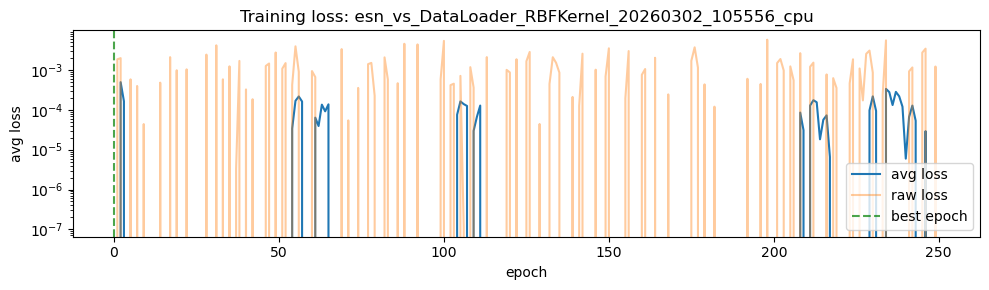

Final average loss: -0.0004
Final loss: -0.0005


In [44]:
losses = plot_loss_from_run(results, kwargs, overlay_raw=True, log_scale=True, overlay_lr = True, mark_best_and_drops=True)
print(f"Final average loss: {losses['avg_losses'][-1]:.4f}")
print(f"Final loss: {losses['losses'][-1]:.4f}")

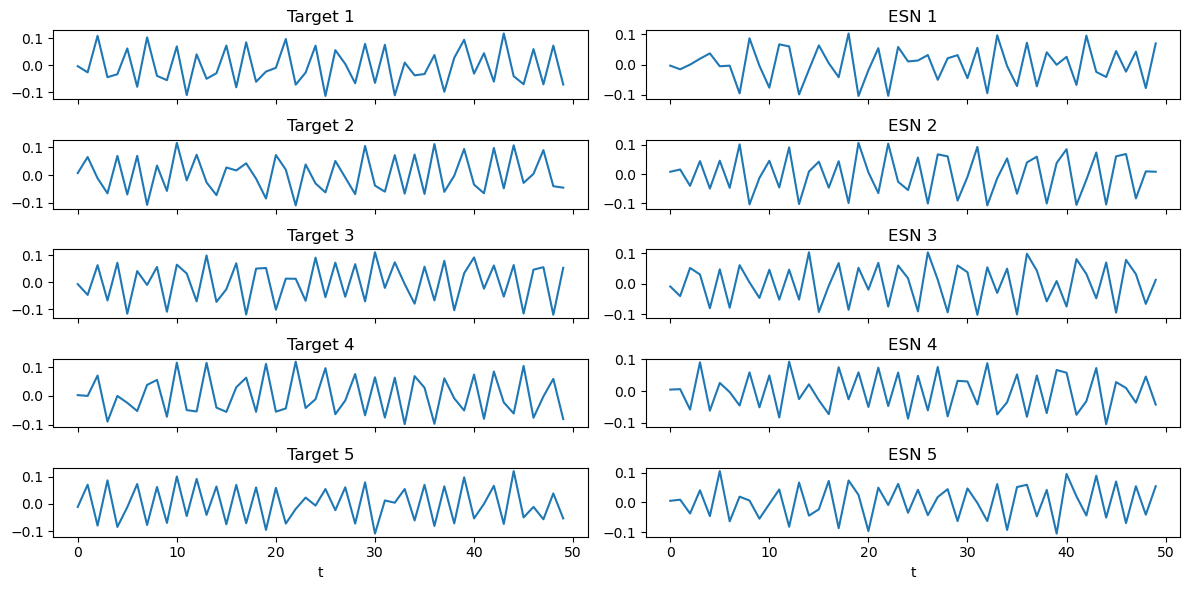

MMD: 0.11218025071176463


In [45]:
# is use generator can pick _T_mmd and _N_mmd for MMD computation
inspection = inspect_run_and_mmd(results, kwargs, n_examples=5, kernel_mmd = sig_disc_kernel, _T_mmd=None, _N_mmd=None, use_best=True)   

# ACF analysis

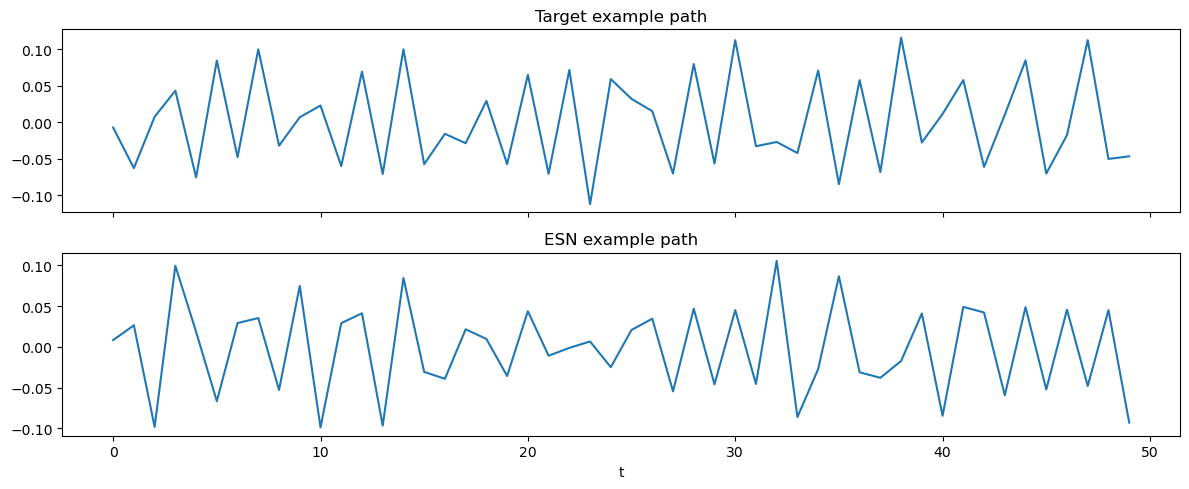

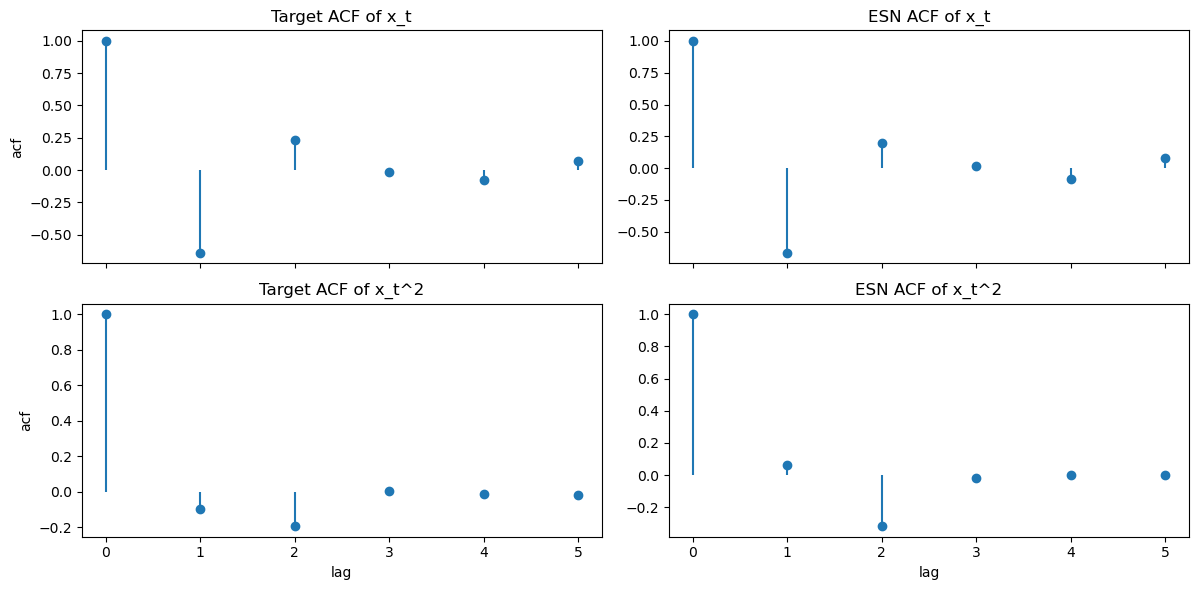

In [46]:
out = acf_analysis(results, kwargs, T_acf=1000, N_paths=100, lag_acf=5)

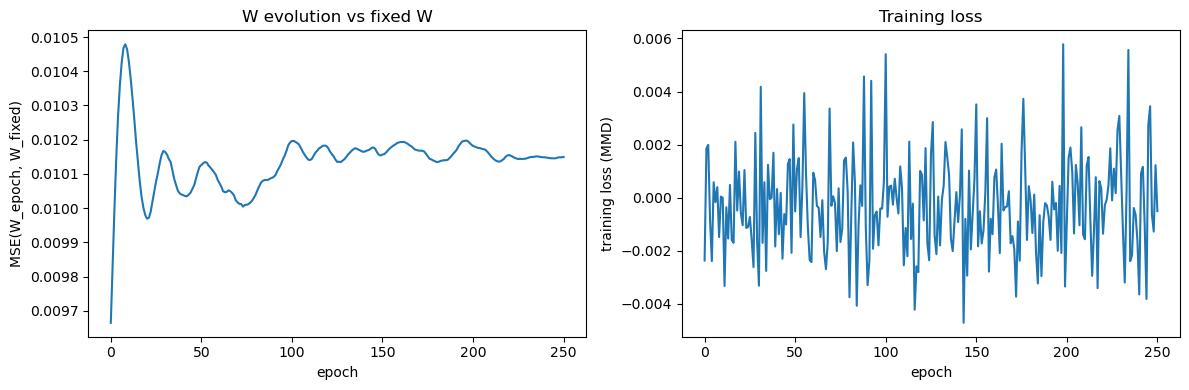

E[W_fixed^2] = 0.0026993502397090197
relative MSE  = 3.759979217822992
||W_fixed||_F = 0.08998917043209076
||W_NN||_F = 0.09287530830757147
||diff||_F    = 0.17449499253581524
Correlation of W_fixed and W_NN = -0.9211424690536779


In [47]:
W_analysis = plot_W_history_vs_fixed(results["run_path"], W_fixed)

# Try LBFGS

In [48]:
from models.trainer_ESM_MMD_LBFGS import *

In [49]:
# generate some sample paths
noise = Noise("normal")
with torch.no_grad():
    X = target_generator.generate(N=N, noise=noise).to(device=device, dtype=dtype)

print(f"Generated data shapes: X: {X.shape}, Z: {Z.shape}")

Generated data shapes: X: torch.Size([1000, 50, 1]), Z: torch.Size([1000, 50, 1])


In [55]:
print(f"Using kernel: {kernel.__class__.__name__} with kernel mode: {kernel_mode}")
out = fit_W_by_lbfgs_mmd(
    esn=esn,
    Z_target=X,
    kernel=kernel,
    kernel_mode=kernel_mode,   # "static" or "sequential"
    N_model=2000,           # how many ESN paths to sample for MMD
    lead_lag=False,
    lags=0,
    max_iter=1000,
    lr=1.0,
    force_float64=True,
    verbose=True,
)

W_fit = out["W_fit"]

Using kernel: RBFKernel with kernel mode: static
MMD initial: -8.722100863522986e-05
MMD final: -9.185566880176577e-05


E[W_fixed^2]          = 0.00269935
MSE(W_fit, W_fixed)   = 0.00115797
relative MSE          = 0.42898
||W_fixed||_F         = 0.0899892
||W_fit||_F           = 0.100566
||W_fit-W_fixed||_F   = 0.0589398
relative Frobenius    = 0.654965
Corr(flattened)       = 0.849627
W_fit[:5]             = [-0.01226791 -0.09293548  0.03641334]
W_fixed[:5]           = [-0.03429345 -0.04818884  0.06782217]


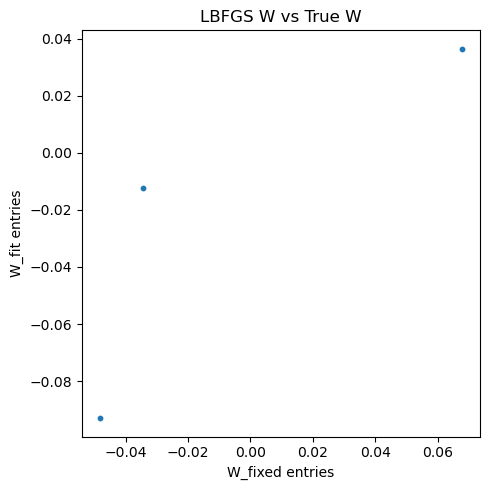

In [56]:
stats = compare_Ws(
    W_fit=W_fit,
    W_fixed=W_fixed,
    title="LBFGS W vs True W",
    scatter=True,
)